In [229]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 1: Load and Preprocess the Text Data



In [230]:

# Load text files
def load_text_files(folder_path, num_files=1000):
    texts = []
    filenames = []
    for file in os.listdir(folder_path)[:num_files]:
        file_path = os.path.join(folder_path, file)
        with open(file_path, 'r', encoding='utf-8') as f:
            texts.append(f.read())
            filenames.append(file)
    return texts, filenames

folder_path = "dataset_generate/news_paper_text_files"  # Replace with your folder path
texts, filenames = load_text_files(folder_path)


### 1. Basic Info: Number of Files and Sample Text


In [231]:
print(f"Total Files Loaded: {len(texts)}")
print("\nSample File Preview:\n")
print(texts[0][:500])  # Preview first 500 chars of first file


Total Files Loaded: 1000

Sample File Preview:

Olympic athletes dedicate years to perfecting their craft.
Soccer fans celebrated wildly after their team's victory.
Soccer fans celebrated wildly after their team's victory.
Esports are gaining recognition as competitive sports.
Sports scholarships help students pursue higher education.
Swimming is one of the most physically demanding sports.
Tennis tournaments attract thousands of fans worldwide.
Soccer fans celebrated wildly after their team's victory.
Boxing matches often end with knockout p


### 2. File Length Distribution


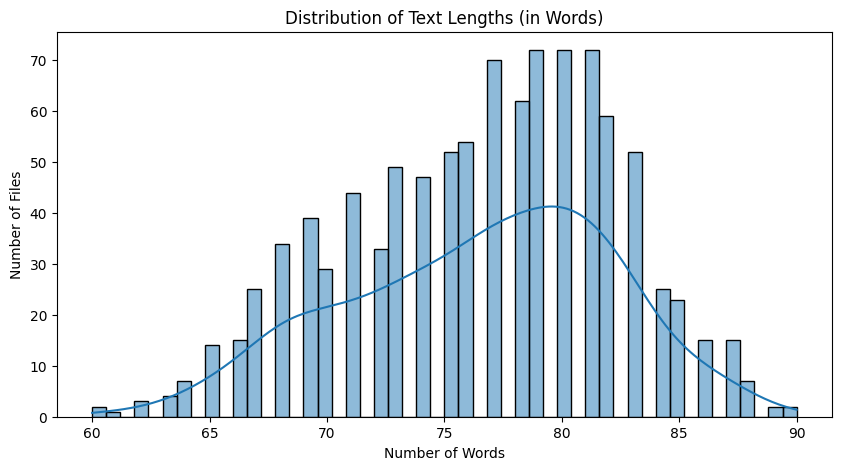

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

file_lengths = [len(text.split()) for text in texts]

plt.figure(figsize=(10, 5))
sns.histplot(file_lengths, bins=50, kde=True)
plt.title("Distribution of Text Lengths (in Words)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Files")
plt.show()


### 3. Check for Empty or Very Short Files

In [233]:
empty_or_short_files =[i for i, length in enumerate(file_lengths) if length <50]
print(f"Files with <50  words: {len(empty_or_short_files)}")


Files with <50  words: 0


In [234]:
file_lengths = [len(text.split()) for text in texts]
print('files length', len(file_lengths))

files length 1000


In [235]:
empty_or_short_files = [i for i, length in enumerate(file_lengths) if length < 10]
print(f"Files with <10 words: {len(empty_or_short_files)}")


Files with <10 words: 0


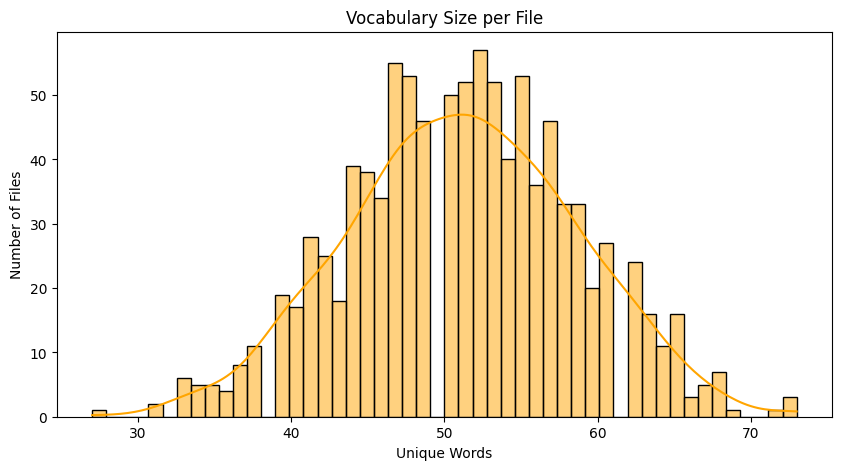

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns
vocab_sizes = [len(set(text.split())) for text in texts]

plt.figure(figsize=(10, 5))
sns.histplot(vocab_sizes, bins=50, kde=True, color='orange')
plt.title("Vocabulary Size per File")
plt.xlabel("Unique Words")
plt.ylabel("Number of Files")
plt.show()


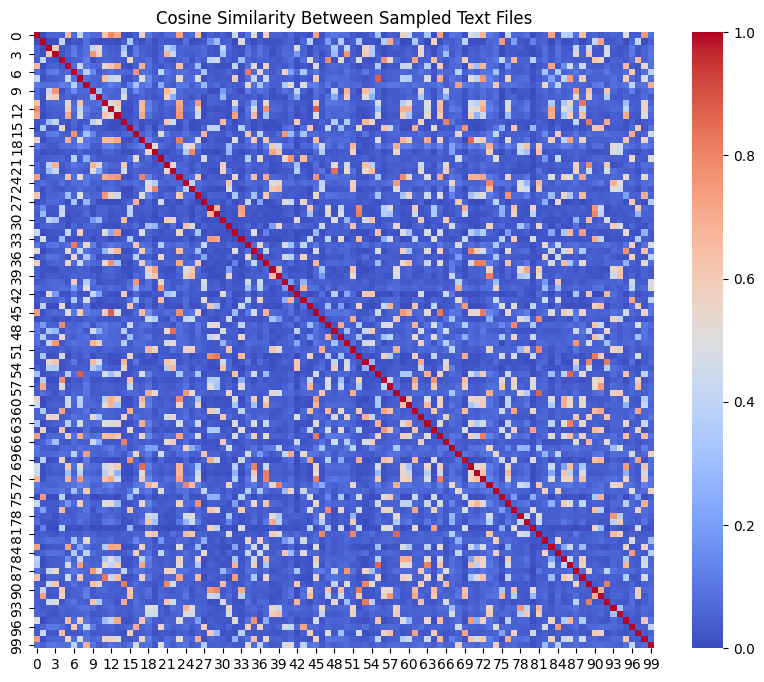

In [237]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(texts)

# Sample 100 documents to reduce computation
sample_indices = random.sample(range(len(texts)), 100)
similarity_matrix = cosine_similarity(X_tfidf[sample_indices])

# Plot a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='coolwarm')
plt.title("Cosine Similarity Between Sampled Text Files")
plt.show()


In [238]:
random_indices = random.sample(range(len(texts)), 100)
random_selected_texts = [texts[i] for i in random_indices]
random_selected_filenames = [filenames[i] for i in random_indices]


In [239]:
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(texts)

# Apply K-Means Clustering
num_clusters = 10  # Adjust as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Select representative samples from each cluster
selected_indices = []
for cluster in range(num_clusters):
    cluster_indices = np.where(clusters == cluster)[0]
    selected_indices.extend(random.sample(list(cluster_indices), min(10, len(cluster_indices))))

structured_selected_texts = [texts[i] for i in selected_indices]
structured_selected_filenames = [filenames[i] for i in selected_indices]


In [240]:
# Generate labels (simulated binary labels for comparison)
labels = np.random.randint(0, 2, size=len(texts))

# Prepare datasets for training
X_random = vectorizer.transform(random_selected_texts)
y_random = [labels[i] for i in random_indices]

X_structured = vectorizer.transform(structured_selected_texts)
y_structured = [labels[i] for i in selected_indices]

# Split into train and test sets
X_rand_train, X_rand_test, y_rand_train, y_rand_test = train_test_split(X_random, y_random, test_size=0.2, random_state=42)
X_struct_train, X_struct_test, y_struct_train, y_struct_test = train_test_split(X_structured, y_structured, test_size=0.2, random_state=42)

# Train Logistic Regression Model
model_random = LogisticRegression()
model_random.fit(X_rand_train, y_rand_train)

model_structured = LogisticRegression()
model_structured.fit(X_struct_train, y_struct_train)

# Evaluate Performance
y_rand_pred = model_random.predict(X_rand_test)
y_struct_pred = model_structured.predict(X_struct_test)

random_acc = accuracy_score(y_rand_test, y_rand_pred)
structured_acc = accuracy_score(y_struct_test, y_struct_pred)

print(f"Model Accuracy (Random Selection): {random_acc:.4f}")
print(f"Model Accuracy (Structured Selection - Clustering): {structured_acc:.4f}")


Model Accuracy (Random Selection): 0.4500
Model Accuracy (Structured Selection - Clustering): 0.5000


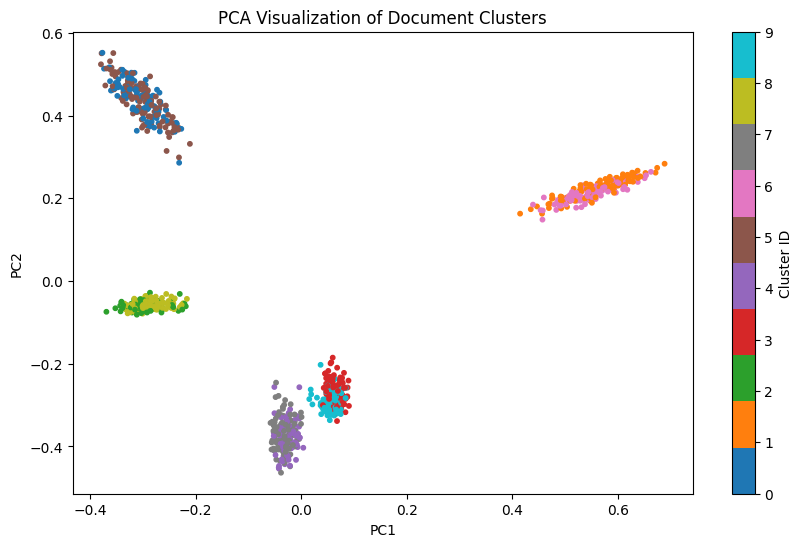

In [241]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=10)
plt.title("PCA Visualization of Document Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


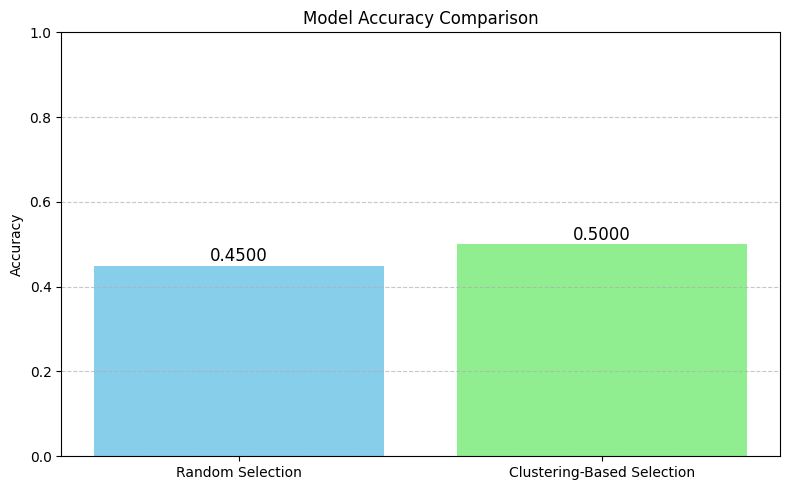

In [242]:
import matplotlib.pyplot as plt
import os

# Ensure the output directory exists
os.makedirs("output", exist_ok=True)

# Accuracies from previous models
accuracies = [random_acc, structured_acc]
methods = ['Random Selection', 'Clustering-Based Selection']

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(methods, accuracies, color=['skyblue', 'lightgreen'])

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', fontsize=12)

plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Save the plot
plt.savefig("output/model_accuracy_comparison_4.png", dpi=300)
plt.close()
